# Deep-Fusion Autoencoder

In this notebook we perform **deep fusion** of our two foundation-model embedding sets:
the **BulkFormer** RNA-seq embeddings (643-dim) and the **CpGPT** DNA-methylation
embeddings (128-dim). The goal is to learn a **shared latent space** that captures
structure common to both modalities, which a downstream classifier can then use to
predict cancer type.

Crucially, **cancer type is never shown to the autoencoder during training**. The
autoencoder is purely unsupervised. We only use cancer-type labels afterward to
*visualize* whether the learned latent space happens to separate the cancer types
(a sign that the latent captured biologically meaningful structure).

### Our architecture: Multi-Input Autoencoder

Rather than concatenating the inputs first (which would be functionally close to early
fusion), we use **modality-specific encoders** that each compress their own modality,
then **fuse** their outputs into the shared latent, and finally use **modality-specific
decoders** to reconstruct each modality independently.

This design means the 64-dim latent must hold enough information to rebuild *both*
the 643-dim expression embedding and the 128-dim methylation embedding â€” encouraging
it to capture what is shared and complementary between the two omics layers.


## Install dependencies

In [43]:
import importlib, subprocess, sys

for pkg in ['umap-learn', 'seaborn']:
    mod = pkg.replace('-', '_')
    try:
        importlib.import_module(mod)
        print(f'  âœ“  {pkg} already installed')
    except ImportError:
        print(f'  Installing {pkg} ...')
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg], check=True)
        print(f'  âœ“  {pkg} installed')

print('\nAll dependencies ready.')

  Installing umap-learn ...
  âœ“  umap-learn installed
  âœ“  seaborn already installed

All dependencies ready.


## Import all required libraries

- **PyTorch** (`torch`) â€” defines and trains the autoencoder.
- **scikit-learn** â€” `StandardScaler` for per-modality normalization, `train_test_split`
  for the stratified validation split, PCA / t-SNE for visualization.
- **umap** â€” non-linear dimensionality reduction for the clearest 2-D latent plot.
- **matplotlib / seaborn** â€” plotting.
- **numpy / pandas** â€” data handling and saving metadata.

In [44]:
import os
import copy
import numpy as np
import pandas as pd
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import matplotlib.pyplot as plt
import seaborn as sns

import umap

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

sns.set_theme(style='whitegrid', context='notebook')
print('All imports successful.')

All imports successful.


## Configuration: paths, hyperparameters, and device

**Hyperparameters** â€” chosen for 800 samples and ~435K parameters:
- `LATENT_DIM = 64` â€” compresses 771 inputs ~12Ã—; strong enough to regularise,
  generous enough to retain signal for 6 classes.
- `BATCH_SIZE = 32`, `LR = 1e-3`, `WEIGHT_DECAY = 1e-5` â€” standard Adam settings.
- `MAX_EPOCHS = 500`, `PATIENCE = 20` â€” early stopping halts training once the
  validation reconstruction loss stops improving, preventing overfitting.

In [45]:
PROJECT_ROOT = Path(r'c:\Users\Bojana\Desktop\Proekti\multi-omics-cancer-classification')
DATA_DIR     = PROJECT_ROOT / 'data' / 'processed'
RESULTS_DIR  = PROJECT_ROOT / 'results' / 'autoencoder'

# Input paths (produced by upstream extraction notebooks)
BULKFORMER_EMB_PATH = DATA_DIR / 'bulkformer_embeddings.npy'
CPGPT_EMB_PATH      = DATA_DIR / 'cpgpt_embeddings.npy'
META_PATH           = DATA_DIR / 'bulkformer_meta.csv'

LATENT_OUT_PATH  = DATA_DIR    / 'autoencoder_embeddings.npy'
MODEL_OUT_PATH   = RESULTS_DIR / 'autoencoder_model.pt'
HISTORY_OUT_PATH = RESULTS_DIR / 'training_history.csv'

required = {
    'BulkFormer embeddings' : BULKFORMER_EMB_PATH,
    'CpGPT embeddings'      : CPGPT_EMB_PATH,
    'Sample metadata'       : META_PATH,
}
all_ok = True
for name, path in required.items():
    status = 'âœ“' if path.exists() else 'âœ—  MISSING'
    print(f'  {status}  {name}: {path}')
    if not path.exists():
        all_ok = False
print('\nAll input files found â€” ready to proceed.' if all_ok else '\nSome files are missing â€” run upstream extraction notebooks first.')

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------------------
# Hyperparameters
# ---------------------------------------------------------------------------
LATENT_DIM   = 64      # shared latent space dimension
BATCH_SIZE   = 32
LR           = 1e-3
WEIGHT_DECAY = 1e-5
MAX_EPOCHS   = 500
PATIENCE     = 20      # early-stopping patience (epochs without improvement)
VAL_SIZE     = 0.20    # 20% validation split
DROPOUT      = 0.30

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'\nDevice      : {device}')
if device.type == 'cuda':
    print(f'GPU         : {torch.cuda.get_device_name(0)}')
print(f'Latent dim  : {LATENT_DIM}')
print(f'Batch size  : {BATCH_SIZE}')
print(f'Max epochs  : {MAX_EPOCHS} (early stopping patience = {PATIENCE})')
print(f'Data dir    : {DATA_DIR}')
print(f'Results dir : {RESULTS_DIR}')

  âœ“  BulkFormer embeddings: c:\Users\Bojana\Desktop\Proekti\multi-omics-cancer-classification\data\processed\bulkformer_embeddings.npy
  âœ“  CpGPT embeddings: c:\Users\Bojana\Desktop\Proekti\multi-omics-cancer-classification\data\processed\cpgpt_embeddings.npy
  âœ“  Sample metadata: c:\Users\Bojana\Desktop\Proekti\multi-omics-cancer-classification\data\processed\bulkformer_meta.csv

All input files found â€” ready to proceed.

Device      : cuda
GPU         : NVIDIA GeForce RTX 4050 Laptop GPU
Latent dim  : 64
Batch size  : 32
Max epochs  : 500 (early stopping patience = 20)
Data dir    : c:\Users\Bojana\Desktop\Proekti\multi-omics-cancer-classification\data\processed
Results dir : c:\Users\Bojana\Desktop\Proekti\multi-omics-cancer-classification\results\autoencoder


## Load the two embedding sets and labels

We load the `.npy` files produced by the two extraction notebooks and the metadata
CSV that links each row to a patient (`case_id`) and cancer type.

The two extraction notebooks drew from the same underlying TCGA samples in the same
order, so row *i* in BulkFormer corresponds to row *i* in CpGPT (the same patient).
We verify this assumption by checking that the row counts match exactly.

In [46]:
# Load embeddings
bulkformer_emb = np.load(BULKFORMER_EMB_PATH)
cpgpt_emb      = np.load(CPGPT_EMB_PATH)

print(f'BulkFormer embeddings : {bulkformer_emb.shape}  (dtype {bulkformer_emb.dtype})')
print(f'CpGPT embeddings      : {cpgpt_emb.shape}  (dtype {cpgpt_emb.dtype})')

# Load metadata (case_id + cancer_type)
meta_df = pd.read_csv(META_PATH)
print(f'Metadata              : {meta_df.shape}  columns={list(meta_df.columns)}')

# ---------------------------------------------------------------------------
# Sanity checks
# ---------------------------------------------------------------------------
assert bulkformer_emb.shape[0] == cpgpt_emb.shape[0], \
    f'Row count mismatch: BulkFormer={bulkformer_emb.shape[0]}, CpGPT={cpgpt_emb.shape[0]}'
assert bulkformer_emb.shape[0] == len(meta_df), \
    f'Metadata row count ({len(meta_df)}) != embedding row count ({bulkformer_emb.shape[0]})'
assert not np.isnan(bulkformer_emb).any(), 'BulkFormer embeddings contain NaN!'
assert not np.isnan(cpgpt_emb).any(),      'CpGPT embeddings contain NaN!'
assert not np.isinf(bulkformer_emb).any(), 'BulkFormer embeddings contain Inf!'
assert not np.isinf(cpgpt_emb).any(),      'CpGPT embeddings contain Inf!'

N = bulkformer_emb.shape[0]
labels = meta_df['cancer_type'].values
case_ids = meta_df['case_id'].values

print(f'\nAll sanity checks passed.  N = {N} patients')
print(f'\nSamples per cancer type:')
print(meta_df['cancer_type'].value_counts().to_string())
print(f'\nBulkFormer value range : [{bulkformer_emb.min():.3f}, {bulkformer_emb.max():.3f}]  '
      f'(mean {bulkformer_emb.mean():.3f}, std {bulkformer_emb.std():.3f})')
print(f'CpGPT value range      : [{cpgpt_emb.min():.3f}, {cpgpt_emb.max():.3f}]  '
      f'(mean {cpgpt_emb.mean():.3f}, std {cpgpt_emb.std():.3f})')

BulkFormer embeddings : (800, 643)  (dtype float32)
CpGPT embeddings      : (800, 128)  (dtype float32)
Metadata              : (800, 2)  columns=['case_id', 'cancer_type']

All sanity checks passed.  N = 800 patients

Samples per cancer type:
cancer_type
TCGA-BRCA    134
TCGA-LUAD    134
TCGA-COAD    133
TCGA-KIRC    133
TCGA-LIHC    133
TCGA-THCA    133

BulkFormer value range : [-2.332, 2.471]  (mean 0.004, std 0.523)
CpGPT value range      : [-0.981, 12.067]  (mean 0.028, std 1.025)


## Preprocessing: per-modality standardization

The two embedding sets live on **very different numeric scales**:
- BulkFormer: range â‰ˆ [-2.33, 2.47], std â‰ˆ 0.52
- CpGPT:      range â‰ˆ [-0.10, 0.07], std â‰ˆ 0.04

If we fed them to the autoencoder as-is, the **reconstruction loss would be dominated
by BulkFormer** (its squared errors are ~150Ã— larger), so the autoencoder would
effectively ignore the methylation modality. Standardizing each modality independently
to zero mean and unit variance puts them on an equal footing, so the shared latent
is pressured to represent *both* modalities.

We fit the scalers on the **training split only** (to avoid leaking validation-set
statistics into training), then apply them to both splits. The scalers are also kept
so the same transformation can be reproduced later.

In [47]:
# Stratified train/val split â€” stratified by cancer type so the validation set
# is representative, even though cancer type is NOT used during AE training.
train_idx, val_idx = train_test_split(
    np.arange(N), test_size=VAL_SIZE, random_state=SEED, stratify=labels
)
print(f'Training set   : {len(train_idx)} samples')
print(f'Validation set : {len(val_idx)} samples')

# Fit scalers on TRAINING data only, then transform both splits
scaler_bf = StandardScaler().fit(bulkformer_emb[train_idx])
scaler_cg = StandardScaler().fit(cpgpt_emb[train_idx])

bf_train = scaler_bf.transform(bulkformer_emb[train_idx]).astype(np.float32)
cg_train = scaler_cg.transform(cpgpt_emb[train_idx]).astype(np.float32)
bf_val   = scaler_bf.transform(bulkformer_emb[val_idx]).astype(np.float32)
cg_val   = scaler_cg.transform(cpgpt_emb[val_idx]).astype(np.float32)

# Full standardized matrices (for latent extraction after training)
bf_all = scaler_bf.transform(bulkformer_emb).astype(np.float32)
cg_all = scaler_cg.transform(cpgpt_emb).astype(np.float32)

print(f'\nAfter standardization (training set):')
print(f'  BulkFormer : mean {bf_train.mean():.4f}, std {bf_train.std():.4f}')
print(f'  CpGPT      : mean {cg_train.mean():.4f}, std {cg_train.std():.4f}')

# Tensor datasets + loaders
train_ds = TensorDataset(
    torch.tensor(bf_train), torch.tensor(cg_train)
)
val_ds = TensorDataset(
    torch.tensor(bf_val), torch.tensor(cg_val)
)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)

print(f'\nDataLoaders ready: {len(train_loader)} train batches, {len(val_loader)} val batches.')

Training set   : 640 samples
Validation set : 160 samples

After standardization (training set):
  BulkFormer : mean 0.0000, std 0.9992
  CpGPT      : mean -0.0000, std 1.0000

DataLoaders ready: 20 train batches, 5 val batches.


## Define the Multi-Input Autoencoder

The model has four parts:

1. **BulkFormer encoder** (`enc_bf`): 643 â†’ 256 â†’ 128
   Compresses the expression embedding. BatchNorm stabilizes training, ReLU adds
   non-linearity, Dropout (0.3) regularizes so the encoder doesn't memorize.

2. **CpGPT encoder** (`enc_cg`): 128 â†’ 64
   Compresses the methylation embedding with the same regularization.

3. **Fusion layer** (`fusion`): concat(128, 64) = 192 â†’ **64**
   This is the heart of deep fusion. It merges the two modality-specific
   representations into the single **shared latent space**. Everything downstream
   is reconstructed from these 64 numbers.

4. **Decoders** (`dec_bf`, `dec_cg`): 64 â†’ 192 â†’ split â†’ reconstruct each modality
   The shared latent is expanded back to 192, then split into two branches that
   each rebuild their original modality. Reconstructing *both* from the same 64
   numbers is what forces the latent to carry cross-modal information.

**Total parameters â‰ˆ 435K** â€” modest for 800 samples, kept in check by the
undercomplete bottleneck (771 â†’ 64), dropout, batch norm, weight decay, and
early stopping.

In [48]:
class MultiInputAutoencoder(nn.Module):
    def __init__(self, bf_dim=643, cg_dim=128, latent_dim=64, dropout=0.3):
        super().__init__()
        self.bf_dim = bf_dim
        self.cg_dim = cg_dim
        self.latent_dim = latent_dim

        # --- Modality-specific encoders ---
        self.enc_bf = nn.Sequential(
            nn.Linear(bf_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
        )
        self.enc_cg = nn.Sequential(
            nn.Linear(cg_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        # --- Fusion into shared latent ---
        # 128 (from BulkFormer) + 64 (from CpGPT) = 192  ->  latent_dim
        self.fusion = nn.Sequential(
            nn.Linear(128 + 64, latent_dim),
            nn.BatchNorm1d(latent_dim),
            nn.ReLU(),
        )

        # --- Shared expansion back to modality-specific decoder inputs ---
        self.expand = nn.Sequential(
            nn.Linear(latent_dim, 128 + 64),
            nn.BatchNorm1d(128 + 64),
            nn.ReLU(),
        )

        # --- Modality-specific decoders ---
        self.dec_bf = nn.Sequential(
            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, bf_dim),
        )
        self.dec_cg = nn.Sequential(
            nn.Linear(64, cg_dim),
        )

    def encode(self, bf, cg):
        '''Return the shared latent vector for a pair of modality inputs.'''
        h_bf = self.enc_bf(bf)
        h_cg = self.enc_cg(cg)
        fused = torch.cat([h_bf, h_cg], dim=1)
        latent = self.fusion(fused)
        return latent

    def decode(self, latent):
        '''Reconstruct both modalities from the shared latent.'''
        expanded = self.expand(latent)
        h_bf, h_cg = expanded[:, :128], expanded[:, 128:]
        recon_bf = self.dec_bf(h_bf)
        recon_cg = self.dec_cg(h_cg)
        return recon_bf, recon_cg

    def forward(self, bf, cg):
        latent = self.encode(bf, cg)
        recon_bf, recon_cg = self.decode(latent)
        return recon_bf, recon_cg, latent


model = MultiInputAutoencoder(
    bf_dim=bulkformer_emb.shape[1],
    cg_dim=cpgpt_emb.shape[1],
    latent_dim=LATENT_DIM,
    dropout=DROPOUT,
).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f'Multi-Input Autoencoder')
print(f'  BulkFormer encoder : {bulkformer_emb.shape[1]} -> 256 -> 128')
print(f'  CpGPT encoder      : {cpgpt_emb.shape[1]} -> 64')
print(f'  Fusion             : 192 -> {LATENT_DIM}  (shared latent)')
print(f'  Decoder            : {LATENT_DIM} -> 192 -> split -> {bulkformer_emb.shape[1]} + {cpgpt_emb.shape[1]}')
print(f'  Total parameters   : {n_params:,}')


Multi-Input Autoencoder
  BulkFormer encoder : 643 -> 256 -> 128
  CpGPT encoder      : 128 -> 64
  Fusion             : 192 -> 64  (shared latent)
  Decoder            : 64 -> 192 -> split -> 643 + 128
  Total parameters   : 439,363


## Training setup: loss, optimizer, and early stopping

**Loss** â€” the total reconstruction loss is the sum of per-modality MSE:
`L = MSE(recon_bf, bf) + MSE(recon_cg, cg)`. Because both modalities are
standardized, neither dominates the loss.

**Optimizer** â€” Adam with a small weight decay (`1e-5`) for L2 regularization,
reducing overfitting on 800 samples.

**Early stopping** â€” monitors the validation loss and restores the best model
weights once training stops improving. This is the single most important
regularizer here: it prevents the autoencoder from memorizing the training set,
which would produce a latent space that doesn't generalize.

In [49]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)


class EarlyStopping:
    def __init__(self, patience=20, min_delta=1e-5):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = np.inf
        self.counter = 0
        self.best_state = None
        self.stopped_epoch = 0

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            self.best_state = copy.deepcopy(model.state_dict())
        else:
            self.counter += 1
        return self.counter >= self.patience

    def restore(self, model):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)
        return model


early_stop = EarlyStopping(patience=PATIENCE)
print(f'Optimizer : Adam (lr={LR}, weight_decay={WEIGHT_DECAY})')
print(f'Loss      : MSE(BulkFormer) + MSE(CpGPT)')
print(f'Early stop: patience={PATIENCE}')

Optimizer : Adam (lr=0.001, weight_decay=1e-05)
Loss      : MSE(BulkFormer) + MSE(CpGPT)
Early stop: patience=20


## Train the autoencoder

The training loop runs up to `MAX_EPOCHS` epochs. Each epoch:
1. Iterates over training batches, computes the reconstruction loss, backpropagates.
2. Evaluates the loss on the validation set (no gradients).
3. Checks early stopping â€” if validation loss hasn't improved for `PATIENCE` epochs,
   training halts and the best weights are restored.

Because the inputs are small 771-dim vectors (not images), each epoch takes
milliseconds. Total training is typically **1â€“5 minutes** on CPU, under a minute on GPU.

We track per-epoch train and validation losses for the training-curve plot.

In [52]:
from tqdm import tqdm

# Re-initialize every time this cell runs so re-runs always start clean
model = MultiInputAutoencoder(
    bf_dim=bulkformer_emb.shape[1],
    cg_dim=cpgpt_emb.shape[1],
    latent_dim=LATENT_DIM,
    dropout=DROPOUT,
).to(device)
optimizer  = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
early_stop = EarlyStopping(patience=PATIENCE)
train_losses, val_losses = [], []
best_epoch = 0

pbar = tqdm(range(1, MAX_EPOCHS + 1), desc='Training AE')
for epoch in pbar:
    # --- Train ---
    model.train()
    epoch_loss = 0.0
    for bf_batch, cg_batch in train_loader:
        bf_batch, cg_batch = bf_batch.to(device), cg_batch.to(device)
        optimizer.zero_grad()
        recon_bf, recon_cg, _ = model(bf_batch, cg_batch)
        loss = criterion(recon_bf, bf_batch) + criterion(recon_cg, cg_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * bf_batch.size(0)
    train_loss = epoch_loss / len(train_ds)

    # --- Validate ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for bf_batch, cg_batch in val_loader:
            bf_batch, cg_batch = bf_batch.to(device), cg_batch.to(device)
            recon_bf, recon_cg, _ = model(bf_batch, cg_batch)
            vloss = criterion(recon_bf, bf_batch) + criterion(recon_cg, cg_batch)
            val_loss += vloss.item() * bf_batch.size(0)
    val_loss = val_loss / len(val_ds)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    pbar.set_postfix({'train': f'{train_loss:.4f}', 'val': f'{val_loss:.4f}'})

    if early_stop(val_loss, model):
        early_stop.restore(model)
        best_epoch = epoch - early_stop.counter
        print(f'Early stopping at epoch {epoch}. Best epoch: {best_epoch} '
              f'(val loss {early_stop.best_loss:.4f})')
        break
    if val_loss == early_stop.best_loss:
        best_epoch = epoch

else:
    early_stop.restore(model)
    print(f'Completed all {MAX_EPOCHS} epochs. Best epoch: {best_epoch} '
          f'(val loss {early_stop.best_loss:.4f})')

print(f' Training complete.')
print(f'  Best validation loss : {early_stop.best_loss:.4f} at epoch {best_epoch}')
print(f'  Final train loss     : {train_losses[-1]:.4f}')
print(f'  Final val loss       : {val_losses[-1]:.4f}')

Training AE:  48%|████▊     | 238/500 [00:29<00:32,  8.02it/s, train=0.2836, val=0.2472]

Early stopping at epoch 239. Best epoch: 219 (val loss 0.2427)
 Training complete.
  Best validation loss : 0.2427 at epoch 219
  Final train loss     : 0.2836
  Final val loss       : 0.2472


## Training curves

Plotting train vs. validation loss per epoch tells us two things:
1. **Did the model converge?** â€” both losses should decrease and plateau.
2. **Is it overfitting?** â€” if validation loss starts rising while training loss
   keeps falling, the model is memorizing the training set. Early stopping should
   prevent this; the vertical line marks the best (lowest-validation) epoch.

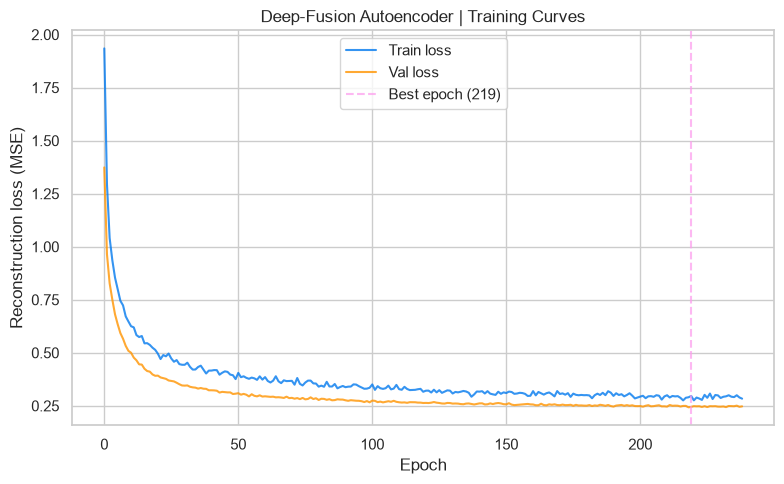

Saved: c:\Users\Bojana\Desktop\Proekti\multi-omics-cancer-classification\results\autoencoder\training_curves.png


In [57]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_losses, label='Train loss', color='#0279EE', alpha=0.8)
ax.plot(val_losses,   label='Val loss',   color='#FF9400', alpha=0.8)
ax.axvline(best_epoch, color='#FD9BED', linestyle='--', alpha=0.7,
           label=f'Best epoch ({best_epoch})')
ax.set_xlabel('Epoch')
ax.set_ylabel('Reconstruction loss (MSE)')
ax.set_title('Deep-Fusion Autoencoder | Training Curves')
ax.legend()
fig.tight_layout()
fig.savefig(RESULTS_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
fig.savefig(RESULTS_DIR / 'training_curves.svg', bbox_inches='tight')
plt.show()
print(f'Saved: {RESULTS_DIR / "training_curves.png"}')

## Extract the shared latent vectors for all samples

Now that the autoencoder is trained, we run the **encoder** on all 800 samples
(training + validation) to obtain the 64-dim shared latent vector for each patient.
These latent vectors are the **deep-fusion representation** that a downstream
classifier will consume.

We use `model.eval()` and `torch.no_grad()` so dropout and batch norm behave in
inference mode and no gradients are stored.

In [54]:
model.eval()
with torch.no_grad():
    bf_tensor = torch.tensor(bf_all).to(device)
    cg_tensor = torch.tensor(cg_all).to(device)
    latent_vectors = model.encode(bf_tensor, cg_tensor).cpu().numpy()

print(f'Latent vectors shape : {latent_vectors.shape}  (N_samples Ã— LATENT_DIM)')
print(f'Value range          : [{latent_vectors.min():.3f}, {latent_vectors.max():.3f}]')
print(f'Mean / Std           : {latent_vectors.mean():.3f} / {latent_vectors.std():.3f}')
assert not np.isnan(latent_vectors).any(), 'Latent vectors contain NaN!'
assert latent_vectors.shape == (N, LATENT_DIM)

Latent vectors shape : (800, 64)  (N_samples Ã— LATENT_DIM)
Value range          : [0.000, 3.849]
Mean / Std           : 0.553 / 0.628


## UMAP visualization of the latent space

**UMAP** is a non-linear dimensionality-reduction method that excels at preserving both local and global structure. We project the 64-dim latent vectors down to 2-D and color each point by cancer type.

**What to look for:** if the autoencoder learned biologically meaningful structure
*without ever seeing the labels*, cancer types should form visible clusters. Tight,
well-separated clusters mean the latent space cleanly separates the cancer types â€”
a strong sign that deep fusion captured cross-modal signal. Overlapping clusters
mean the latent captured other (possibly batch or technical) structure instead.

c:\Users\Bojana\Desktop\Proekti\multi-omics-cancer-classification\venv_bulkformer\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


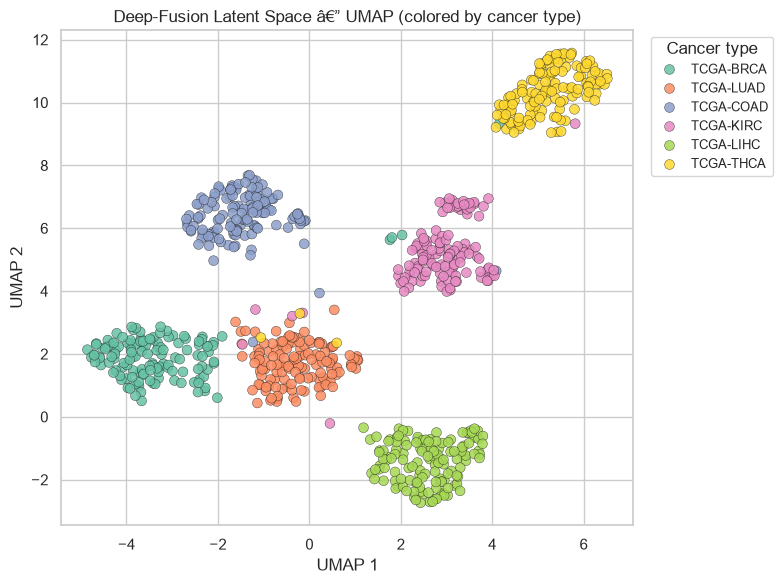

Saved: c:\Users\Bojana\Desktop\Proekti\multi-omics-cancer-classification\results\autoencoder\umap_autoencoder.png


In [55]:
reducer = umap.UMAP(n_components=2, random_state=SEED, n_neighbors=30, min_dist=0.3)
latent_2d_umap = reducer.fit_transform(latent_vectors)

fig, ax = plt.subplots(figsize=(8, 6))
palette = sns.color_palette('Set2', n_colors=len(np.unique(labels)))
sns.scatterplot(
    x=latent_2d_umap[:, 0], y=latent_2d_umap[:, 1],
    hue=labels, palette=palette, s=50, alpha=0.85, edgecolor='k', linewidth=0.3, ax=ax,
)
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title('Deep-Fusion Latent Space â€” UMAP (colored by cancer type)')
ax.legend(title='Cancer type', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
fig.tight_layout()
fig.savefig(RESULTS_DIR / 'umap_autoencoder.png', dpi=150, bbox_inches='tight')
fig.savefig(RESULTS_DIR / 'umap_autoencoder.svg', bbox_inches='tight')
plt.show()
print(f'Saved: {RESULTS_DIR / "umap_autoencoder.png"}')

## t-SNE visualization of the latent space

**t-SNE** is another non-linear projection that focuses on preserving *local*
neighborhoods. It's a good complement to UMAP: if both methods show similar
clustering, we can be more confident the structure is real and not an artifact
of one algorithm.

We use `init='pca'` for a stable initialization and `perplexity=30` (a reasonable
value for 800 samples â€” roughly N/25).

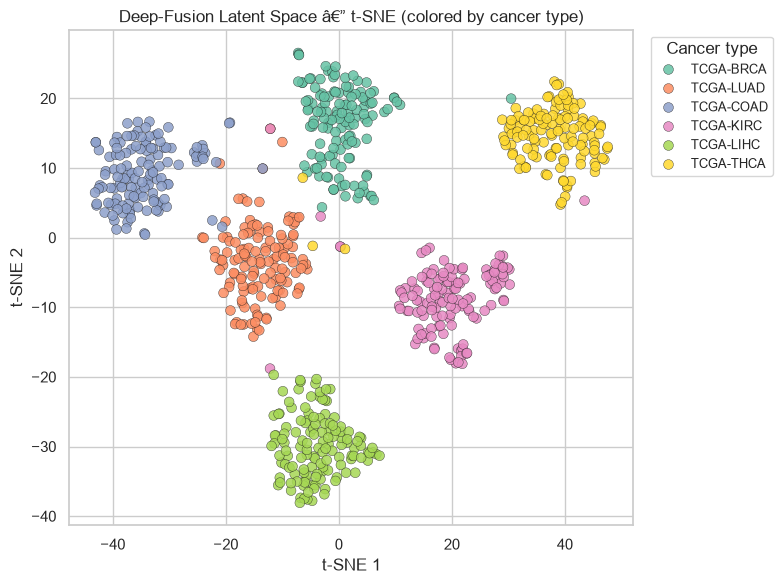

Saved: c:\Users\Bojana\Desktop\Proekti\multi-omics-cancer-classification\results\autoencoder\tsne_autoencoder.png


In [56]:
tsne = TSNE(n_components=2, random_state=SEED, perplexity=30,
            init='pca', learning_rate='auto', max_iter=1000)
latent_2d_tsne = tsne.fit_transform(latent_vectors)

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    x=latent_2d_tsne[:, 0], y=latent_2d_tsne[:, 1],
    hue=labels, palette=palette, s=50, alpha=0.85, edgecolor='k', linewidth=0.3, ax=ax,
)
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_title('Deep-Fusion Latent Space â€” t-SNE (colored by cancer type)')
ax.legend(title='Cancer type', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
fig.tight_layout()
fig.savefig(RESULTS_DIR / 'tsne_autoencoder.png', dpi=150, bbox_inches='tight')
fig.savefig(RESULTS_DIR / 'tsne_autoencoder.svg', bbox_inches='tight')
plt.show()
print(f'Saved: {RESULTS_DIR / "tsne_autoencoder.png"}')

## PCA visualization of the latent space

**PCA** is a *linear* projection â€” it captures the directions of maximum variance
in the latent space. Unlike UMAP/t-SNE, it preserves global distances and lets us
see **how many latent dimensions actually carry signal** via the explained-variance
bar chart.

If the first 2â€“3 PCs explain most of the variance and separate the cancer types,
the latent space is low-rank and highly structured. If variance is spread evenly
across all 64 dims, the autoencoder distributed information broadly.

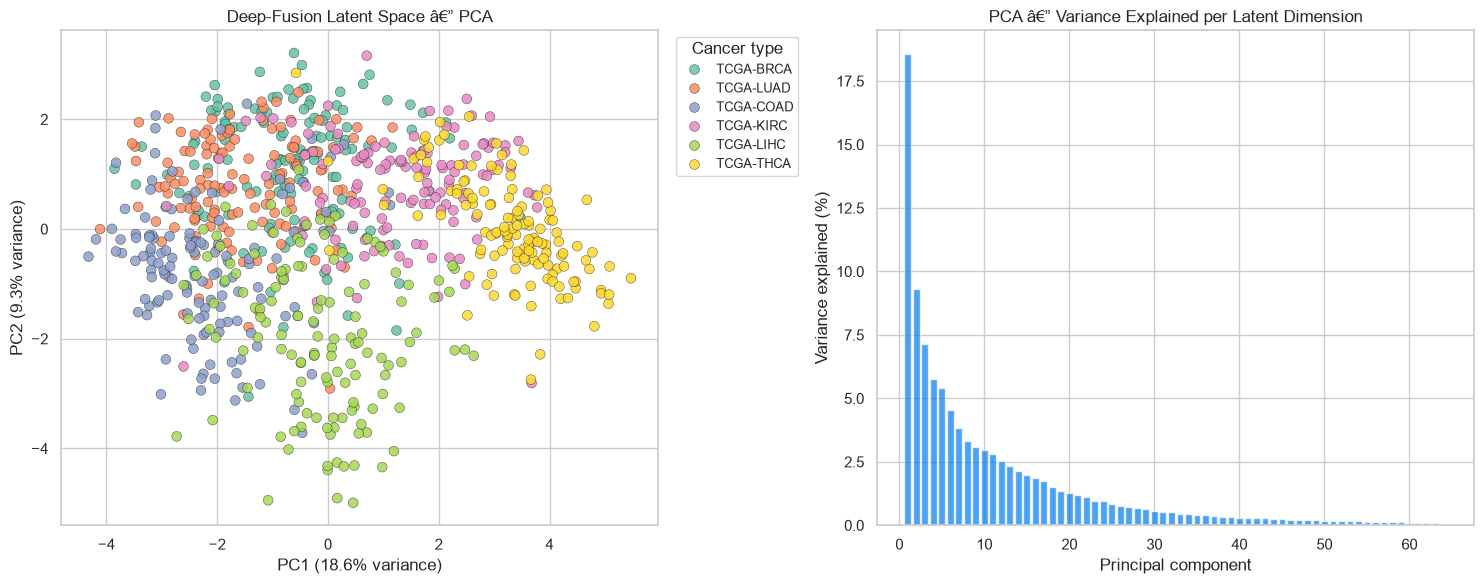

Saved: c:\Users\Bojana\Desktop\Proekti\multi-omics-cancer-classification\results\autoencoder\pca_autoencoder.png

Top 5 PCs explain 46.2% of variance


In [58]:
pca = PCA(n_components=LATENT_DIM)
latent_pca = pca.fit_transform(latent_vectors)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: first two PCs
sns.scatterplot(
    x=latent_pca[:, 0], y=latent_pca[:, 1],
    hue=labels, palette=palette, s=50, alpha=0.85, edgecolor='k', linewidth=0.3, ax=axes[0],
)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
axes[0].set_title('Deep-Fusion Latent Space â€” PCA')
axes[0].legend(title='Cancer type', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)

# Right: explained variance bar chart
axes[1].bar(range(1, LATENT_DIM + 1), pca.explained_variance_ratio_ * 100,
            color='#0279EE', alpha=0.7)
axes[1].set_xlabel('Principal component')
axes[1].set_ylabel('Variance explained (%)')
axes[1].set_title('PCA â€” Variance Explained per Latent Dimension')

fig.tight_layout()
fig.savefig(RESULTS_DIR / 'pca_autoencoder.png', dpi=150, bbox_inches='tight')
fig.savefig(RESULTS_DIR / 'pca_autoencoder.svg', bbox_inches='tight')
plt.show()
print(f'Saved: {RESULTS_DIR / "pca_autoencoder.png"}')
print(f'\nTop 5 PCs explain {pca.explained_variance_ratio_[:5].sum()*100:.1f}% of variance')

## Reconstruction quality

A good autoencoder doesn't just compress â€” it can *rebuild* the inputs from the
compressed latent. We measure reconstruction fidelity two ways:

1. **Per-modality MSE** â€” the reconstruction error for BulkFormer and CpGPT
   separately, on the full standardized dataset. Lower is better; values near the
   validation training loss mean the model generalizes.

2. **Original-vs-reconstructed scatter** â€” for a random subset of samples, we plot
   a few original embedding values against their reconstructions. Points on the
   diagonal y=x line mean perfect reconstruction. Spread around the line shows
   where information was lost in the bottleneck.

Reconstruction MSE (standardized):
  BulkFormer : 0.0907
  CpGPT      : 0.0569
  Total      : 0.1476


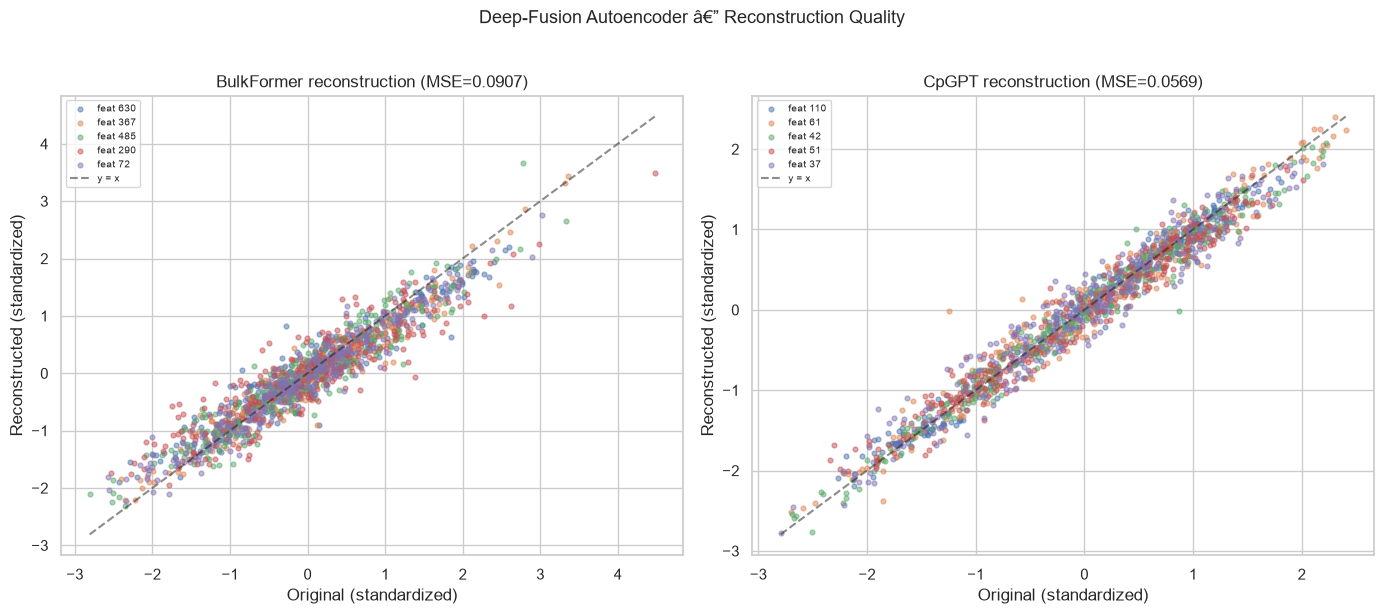

Saved: c:\Users\Bojana\Desktop\Proekti\multi-omics-cancer-classification\results\autoencoder\reconstruction_autoencoder.png


In [59]:
# Reconstruct all samples
model.eval()
with torch.no_grad():
    bf_tensor = torch.tensor(bf_all).to(device)
    cg_tensor = torch.tensor(cg_all).to(device)
    recon_bf, recon_cg, _ = model(bf_tensor, cg_tensor)
    recon_bf = recon_bf.cpu().numpy()
    recon_cg = recon_cg.cpu().numpy()

mse_bf = np.mean((bf_all - recon_bf) ** 2)
mse_cg = np.mean((cg_all - recon_cg) ** 2)
print(f'Reconstruction MSE (standardized):')
print(f'  BulkFormer : {mse_bf:.4f}')
print(f'  CpGPT      : {mse_cg:.4f}')
print(f'  Total      : {mse_bf + mse_cg:.4f}')

# Scatter: pick a few random features per modality
rng = np.random.RandomState(SEED)
n_feat_show = 5
bf_feat_idx = rng.choice(bf_all.shape[1], n_feat_show, replace=False)
cg_feat_idx = rng.choice(cg_all.shape[1], n_feat_show, replace=False)
n_show = 300
show_idx = rng.choice(N, n_show, replace=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# BulkFormer scatter
for j, fi in enumerate(bf_feat_idx):
    axes[0].scatter(bf_all[show_idx, fi], recon_bf[show_idx, fi],
                    s=12, alpha=0.5, label=f'feat {fi}')
# np.ix_ creates an open mesh so we can index (300 rows) Ã— (5 cols) simultaneously
bf_sub    = bf_all[np.ix_(show_idx, bf_feat_idx)]
recon_sub = recon_bf[np.ix_(show_idx, bf_feat_idx)]
lims_bf   = [min(bf_sub.min(), recon_sub.min()), max(bf_sub.max(), recon_sub.max())]
axes[0].plot(lims_bf, lims_bf, 'k--', alpha=0.5, label='y = x')
axes[0].set_xlabel('Original (standardized)')
axes[0].set_ylabel('Reconstructed (standardized)')
axes[0].set_title(f'BulkFormer reconstruction (MSE={mse_bf:.4f})')
axes[0].legend(fontsize=7, loc='upper left')

# CpGPT scatter
for j, fi in enumerate(cg_feat_idx):
    axes[1].scatter(cg_all[show_idx, fi], recon_cg[show_idx, fi],
                    s=12, alpha=0.5, label=f'feat {fi}')
cg_sub       = cg_all[np.ix_(show_idx, cg_feat_idx)]
recon_cg_sub = recon_cg[np.ix_(show_idx, cg_feat_idx)]
lims_cg      = [min(cg_sub.min(), recon_cg_sub.min()), max(cg_sub.max(), recon_cg_sub.max())]
axes[1].plot(lims_cg, lims_cg, 'k--', alpha=0.5, label='y = x')
axes[1].set_xlabel('Original (standardized)')
axes[1].set_ylabel('Reconstructed (standardized)')
axes[1].set_title(f'CpGPT reconstruction (MSE={mse_cg:.4f})')
axes[1].legend(fontsize=7, loc='upper left')

fig.suptitle('Deep-Fusion Autoencoder â€” Reconstruction Quality', y=1.02, fontsize=13)
fig.tight_layout()
fig.savefig(RESULTS_DIR / 'reconstruction_autoencoder.png', dpi=150, bbox_inches='tight')
fig.savefig(RESULTS_DIR / 'reconstruction_autoencoder.svg', bbox_inches='tight')
plt.show()
print(f'Saved: {RESULTS_DIR / "reconstruction_autoencoder.png"}')

## Latent dimension comparison

To justify the choice of `LATENT_DIM = 64`, we train compact autoencoders with
latent dimensions of **32, 64, and 128** and compare their best validation
reconstruction loss.

- **Smaller latent (32)** â€” stronger compression. If the loss jumps a lot, 32 is
  too small and information is being lost.
- **Larger latent (128)** â€” gentler compression. If the loss barely improves over
  64, the extra capacity isn't buying better reconstruction (and risks overfitting).

The "elbow" of this curve is the sweet spot: small enough to regularize, large
enough to retain signal. We expect 64 to sit at or near that elbow.

Sweeping latent dimensions...
  latent_dim= 32  ->  best val loss = 0.2696
  latent_dim= 64  ->  best val loss = 0.2567
  latent_dim=128  ->  best val loss = 0.2485


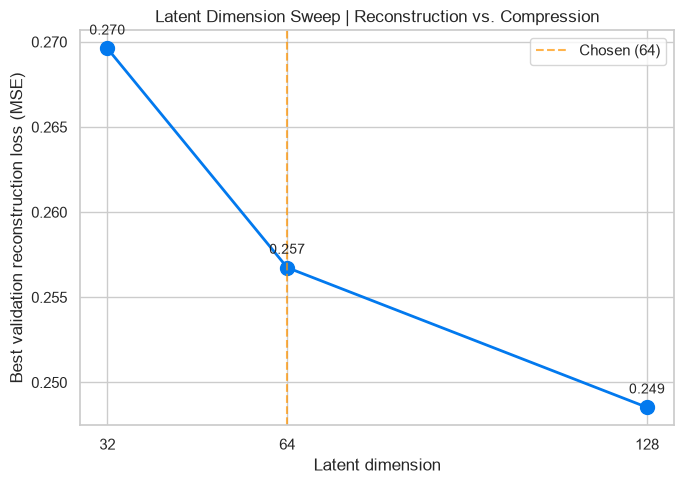


Saved: c:\Users\Bojana\Desktop\Proekti\multi-omics-cancer-classification\results\autoencoder\latent_dim_sweep.png


In [61]:
def train_ae_for_latent_dim(latent_dim, train_loader, val_loader, val_ds,
                           bf_dim, cg_dim, max_epochs=300, patience=15):
    '''Train a multi-input AE with a given latent dim and return best val loss.'''
    m = MultiInputAutoencoder(bf_dim=bf_dim, cg_dim=cg_dim,
                              latent_dim=latent_dim, dropout=DROPOUT).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    es = EarlyStopping(patience=patience)

    for epoch in range(1, max_epochs + 1):
        m.train()
        for bf_b, cg_b in train_loader:
            bf_b, cg_b = bf_b.to(device), cg_b.to(device)
            opt.zero_grad()
            rb, rc, _ = m(bf_b, cg_b)
            loss = criterion(rb, bf_b) + criterion(rc, cg_b)
            loss.backward()
            opt.step()
        m.eval()
        vloss = 0.0
        with torch.no_grad():
            for bf_b, cg_b in val_loader:
                bf_b, cg_b = bf_b.to(device), cg_b.to(device)
                rb, rc, _ = m(bf_b, cg_b)
                vloss += (criterion(rb, bf_b) + criterion(rc, cg_b)).item() * bf_b.size(0)
        vloss /= len(val_ds)
        if es(vloss, m):
            es.restore(m)
            break
    else:
        es.restore(m)
    return es.best_loss


latent_dims = [32, 64, 128]
val_losses_sweep = []
print('Sweeping latent dimensions...')
for ld in latent_dims:
    vl = train_ae_for_latent_dim(ld, train_loader, val_loader, val_ds,
                                 bulkformer_emb.shape[1], cpgpt_emb.shape[1])
    val_losses_sweep.append(vl)
    print(f'  latent_dim={ld:3d}  ->  best val loss = {vl:.4f}')

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(latent_dims, val_losses_sweep, 'o-', color='#0279EE', markersize=10, linewidth=2)
ax.axvline(LATENT_DIM, color='#FF9400', linestyle='--', alpha=0.7, label=f'Chosen ({LATENT_DIM})')
for ld, vl in zip(latent_dims, val_losses_sweep):
    ax.annotate(f'{vl:.3f}', (ld, vl), textcoords='offset points', xytext=(0, 10), ha='center', fontsize=10)
ax.set_xlabel('Latent dimension')
ax.set_ylabel('Best validation reconstruction loss (MSE)')
ax.set_title('Latent Dimension Sweep | Reconstruction vs. Compression')
ax.set_xticks(latent_dims)
ax.legend()
fig.tight_layout()
fig.savefig(RESULTS_DIR / 'latent_dim_sweep.png', dpi=150, bbox_inches='tight')
fig.savefig(RESULTS_DIR / 'latent_dim_sweep.svg', bbox_inches='tight')
plt.show()
print(f'\nSaved: {RESULTS_DIR / "latent_dim_sweep.png"}')

## Save outputs 

In [62]:
# 1. Fused latent embedding â†’ data/processed/ (input to downstream classifier)
np.save(LATENT_OUT_PATH, latent_vectors)
print(f'Saved latent vectors : {LATENT_OUT_PATH}  shape={latent_vectors.shape}')

# 2. Model weights â†’ results/autoencoder/
torch.save({
    'model_state_dict': model.state_dict(),
    'latent_dim': LATENT_DIM,
    'bf_dim': bulkformer_emb.shape[1],
    'cg_dim': cpgpt_emb.shape[1],
    'best_epoch': best_epoch,
    'best_val_loss': early_stop.best_loss,
}, MODEL_OUT_PATH)
print(f'Saved model weights  : {MODEL_OUT_PATH}')

# 3. Training history â†’ results/autoencoder/
history_df = pd.DataFrame({
    'epoch': range(1, len(train_losses) + 1),
    'train_loss': train_losses,
    'val_loss': val_losses,
})
history_df.to_csv(HISTORY_OUT_PATH, index=False)
print(f'Saved training history : {HISTORY_OUT_PATH}  ({len(history_df)} epochs)')

print(f'\nEmbeddings â†’ {DATA_DIR}')
print(f'All other outputs  â†’ {RESULTS_DIR}')

Saved latent vectors : c:\Users\Bojana\Desktop\Proekti\multi-omics-cancer-classification\data\processed\autoencoder_embeddings.npy  shape=(800, 64)
Saved model weights  : c:\Users\Bojana\Desktop\Proekti\multi-omics-cancer-classification\results\autoencoder\autoencoder_model.pt
Saved training history : c:\Users\Bojana\Desktop\Proekti\multi-omics-cancer-classification\results\autoencoder\training_history.csv  (239 epochs)

Embeddings â†’ c:\Users\Bojana\Desktop\Proekti\multi-omics-cancer-classification\data\processed
All other outputs  â†’ c:\Users\Bojana\Desktop\Proekti\multi-omics-cancer-classification\results\autoencoder
